# Trending YouTube Videos - Data Analysis

This notebook analyzes the **Trending YouTube** dataset, which contains data on trending videos from 10 countries: Canada (CA), Germany (DE), France (FR), Great Britain (GB), India (IN), Japan (JP), South Korea (KR), Mexico (MX), Russia (RU), and the United States (US).

Each country has a CSV file with video metadata (title, channel, tags, views, likes, dislikes, etc.) and a JSON file mapping numeric `category_id` values to human-readable category names.

The notebook works through 15 analysis tasks and then produces a set of charts that are saved as image files in the same folder as the notebook.

## Setup

Install the `zstandard` library needed to decompress the `.zst` compressed CSV files.

In [1]:
pip install zstandard

Note: you may need to restart the kernel to use updated packages.


We also set up `matplotlib` for the charts later on, and create an `images` folder next to the notebook where every plot will be saved as a PNG.

In [2]:
import matplotlib.pyplot as plt
import os

# folder where all the generated charts will be written
IMG_DIR = "images"
os.makedirs(IMG_DIR, exist_ok=True)

plt.rcParams['figure.dpi'] = 110
plt.rcParams['savefig.bbox'] = 'tight'

def save_fig(name):
    path = os.path.join(IMG_DIR, name)
    plt.savefig(path)
    print("saved:", path)

## Task 1 - Create a single dataframe with all countries

We read each country's CSV from the zip archive (they are zstd-compressed inside), add a `country` column with the 2-letter country code, and concatenate everything into a single dataframe.

Note: some CSV files contain non-UTF-8 characters, so we use `encoding_errors='replace'` to handle them gracefully.

In [3]:
import pandas as pd
import zstandard as zstd
import zipfile
import io

zip_path = r"C:\Users\Khurram Shahzad\Desktop\projects\khurram\cs_project\trendingYT.zip"
countries = ['CA', 'DE', 'FR', 'GB', 'IN', 'JP', 'KR', 'MX', 'RU', 'US']

dfs = []
with zipfile.ZipFile(zip_path) as z:
    for country in countries:
        with z.open(f"trendingYT/{country}videos.csv.zst") as f:
            raw = zstd.ZstdDecompressor().decompress(f.read())
        temp = pd.read_csv(io.BytesIO(raw), encoding_errors='replace')
        temp['country'] = country
        dfs.append(temp)

df = pd.concat(dfs, ignore_index=True)
df.shape

(375942, 17)

In [4]:
df['country'].value_counts()

country
US    40949
CA    40881
DE    40840
RU    40739
FR    40724
MX    40451
GB    38916
IN    37352
KR    34567
JP    20523
Name: count, dtype: int64

### Visualization - number of trending entries per country

A quick bar chart of how many trending video rows each country contributes.

saved: images\01_entries_per_country.png


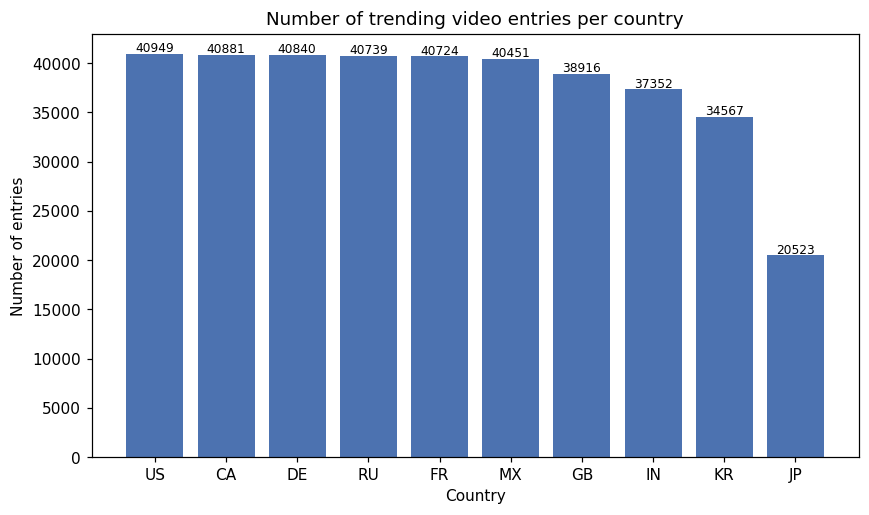

In [5]:
counts = df['country'].value_counts()

plt.figure(figsize=(9, 5))
plt.bar(counts.index, counts.values, color='#4C72B0')
plt.title('Number of trending video entries per country')
plt.xlabel('Country')
plt.ylabel('Number of entries')
for i, v in enumerate(counts.values):
    plt.text(i, v + 200, str(v), ha='center', fontsize=8)
save_fig('01_entries_per_country.png')
plt.show()

## Task 2 - Extract all videos with no tags

Videos without tags have the string `[none]` in the `tags` column. We filter for those rows.

In [6]:
no_tags = df[df['tags'] == '[none]']
no_tags.shape

(37698, 17)

In [7]:
no_tags[['title', 'channel_title', 'tags', 'country']].head()

,title,channel_title,tags,country
41,Canada Soccer's Women's National Team v USA In...,Canada Soccer,[none],CA
58,John Oliver Tackles Louis C.K. And Donald Trum...,TV Shows,[none],CA
78,Taylor Swift Perform Ready For It - SNL,Ken Reactz,[none],CA
86,"LATEST Q POSTS: ROTHSCHILDS, HOUSE OF SAUD, lL...",James Munder,[none],CA
98,三屆TVB視帝，拋棄10年青梅竹馬髮妻，為娶小三還不惜與母絕交！,明星百曉生,[none],CA


### Visualization - videos with no tags by country

Comparing, per country, how many trending videos were published without any tags.

saved: images\02_no_tags_per_country.png


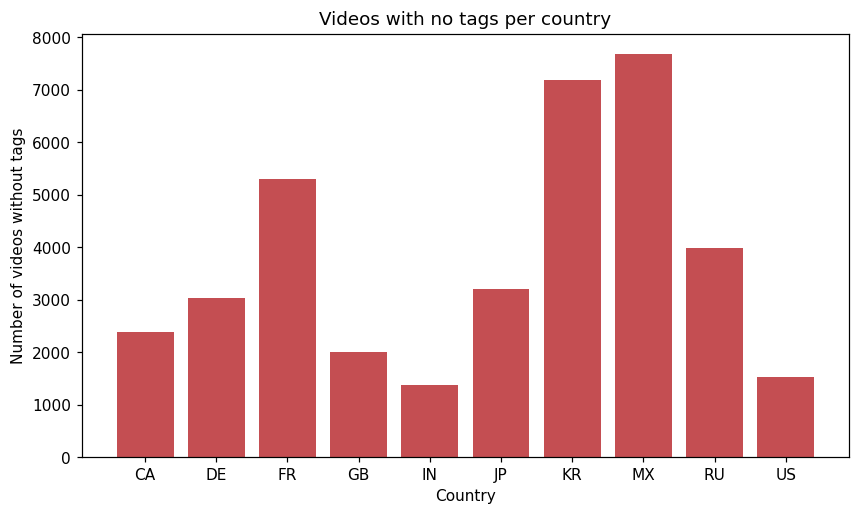

In [8]:
no_tags_by_country = no_tags['country'].value_counts().reindex(countries)

plt.figure(figsize=(9, 5))
plt.bar(no_tags_by_country.index, no_tags_by_country.values, color='#C44E52')
plt.title('Videos with no tags per country')
plt.xlabel('Country')
plt.ylabel('Number of videos without tags')
save_fig('02_no_tags_per_country.png')
plt.show()

## Task 3 - Total views per channel

We group by `channel_title` and sum the `views` column, then sort in descending order to see the most-viewed channels.

In [9]:
views_per_channel = df.groupby('channel_title')['views'].sum()
views_per_channel.sort_values(ascending=False)

channel_title
ChildishGambinoVEVO     11016766510
Marvel Entertainment    10430605449
NickyJamTV               9479859505
Ozuna                    8623329509
ibighit                  8205572221
                           ...     
NavylittleMonster               365
Videostendencias                302
No Comment TV                   284
Sport Life                      163
Alexander Redking               153
Name: views, Length: 37824, dtype: int64

### Visualization - top 10 channels by total views

The 10 channels that accumulated the most views across the whole dataset.

saved: images\03_top_channels_by_views.png


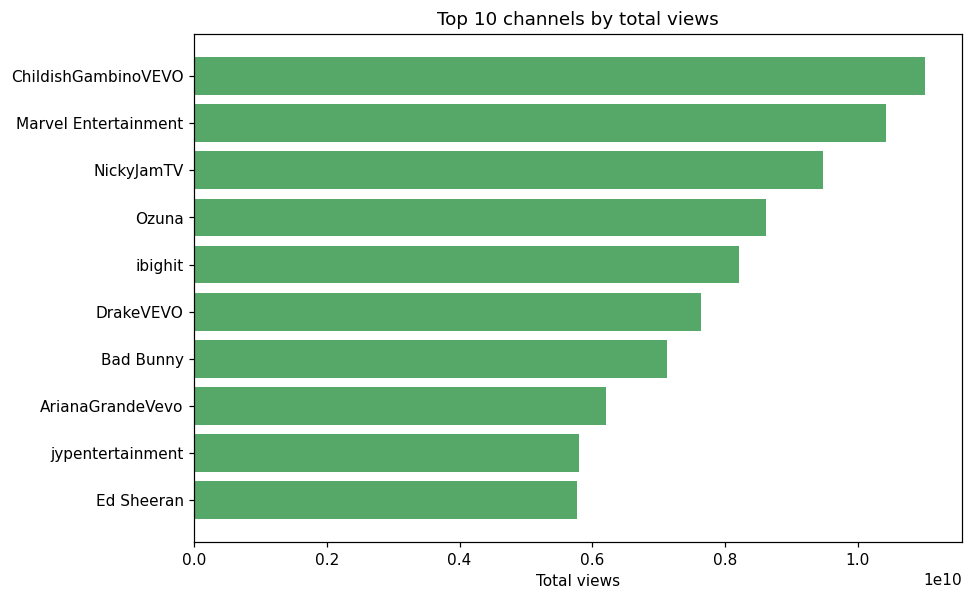

In [10]:
top_channels = views_per_channel.sort_values(ascending=False).head(10)

plt.figure(figsize=(9, 6))
plt.barh(top_channels.index[::-1], top_channels.values[::-1], color='#55A868')
plt.title('Top 10 channels by total views')
plt.xlabel('Total views')
save_fig('03_top_channels_by_views.png')
plt.show()

## Task 4 - Separate excluded videos

We move all rows where `comments_disabled`, `ratings_disabled`, or `video_error_or_removed` is `True` into a new dataframe called `excluded`, and remove them from the original dataframe `df`.

In [11]:
mask = df['comments_disabled'] | df['ratings_disabled'] | df['video_error_or_removed']

excluded = df[mask].copy()
df = df[~mask].copy()

print("excluded:", excluded.shape)
print("df:", df.shape)

excluded: (13657, 17)
df: (362285, 17)


### Visualization - reasons videos were excluded

How many of the excluded rows fall under each of the three flags (a video can trigger more than one).

saved: images\04_exclusion_reasons.png


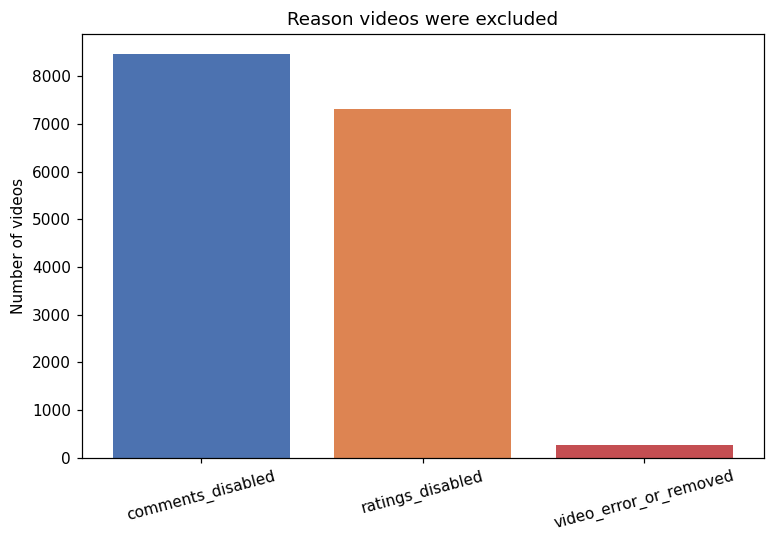

In [12]:
reasons = {
    'comments_disabled': excluded['comments_disabled'].sum(),
    'ratings_disabled': excluded['ratings_disabled'].sum(),
    'video_error_or_removed': excluded['video_error_or_removed'].sum(),
}

plt.figure(figsize=(8, 5))
plt.bar(reasons.keys(), reasons.values(), color=['#4C72B0', '#DD8452', '#C44E52'])
plt.title('Reason videos were excluded')
plt.ylabel('Number of videos')
plt.xticks(rotation=15)
save_fig('04_exclusion_reasons.png')
plt.show()

## Task 5 - Add `like_ratio` column

We compute the ratio of `likes` to `dislikes` for each video. Videos with 0 dislikes will produce `inf` values.

In [13]:
df['like_ratio'] = df['likes'] / df['dislikes']
df[['title', 'likes', 'dislikes', 'like_ratio']].head()

,title,likes,dislikes,like_ratio
0,Eminem - Walk On Water (Audio) ft. Beyoncé,787425,43420,18.135076
1,PLUSH - Bad Unboxing Fan Mail,127794,1688,75.707346
2,"Racist Superman | Rudy Mancuso, King Bach & Le...",146035,5339,27.352500
3,I Dare You: GOING BALD!?,132239,1989,66.485168
4,Ed Sheeran - Perfect (Official Music Video),1634130,21082,77.513044


### Visualization - distribution of the like ratio

A histogram of the like ratio. We drop infinite values (videos with zero dislikes) and cap the axis so the long tail does not flatten the chart.

saved: images\05_like_ratio_distribution.png


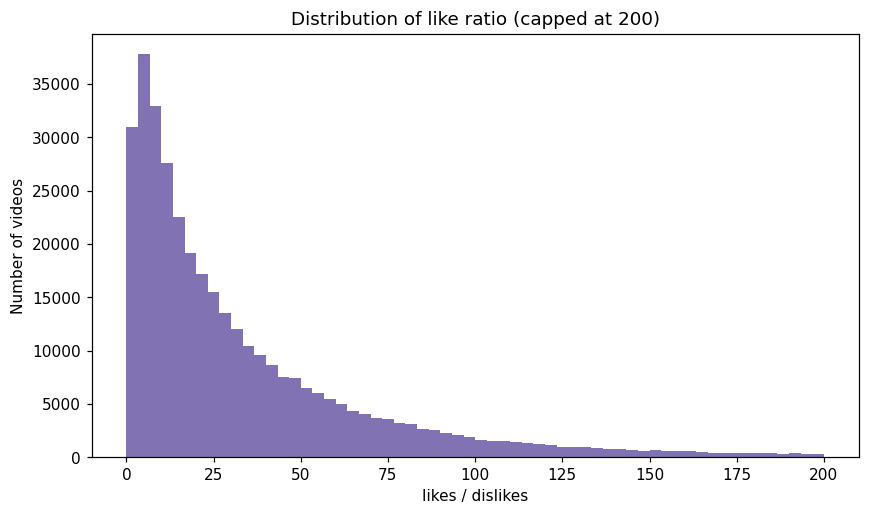

In [14]:
import numpy as np

ratios = df['like_ratio'].replace([np.inf, -np.inf], np.nan).dropna()
ratios_capped = ratios[ratios <= 200]

plt.figure(figsize=(9, 5))
plt.hist(ratios_capped, bins=60, color='#8172B3')
plt.title('Distribution of like ratio (capped at 200)')
plt.xlabel('likes / dislikes')
plt.ylabel('Number of videos')
save_fig('05_like_ratio_distribution.png')
plt.show()

## Task 6 - Cluster publish time into 10-minute intervals

We extract the hour and minute from `publish_time`, floor the minutes to the nearest 10-minute boundary, and store the result as a string (e.g. `"14:30"`).

In [15]:
publish = pd.to_datetime(df['publish_time'])
minutes = publish.dt.hour * 60 + publish.dt.minute
interval_start = (minutes // 10) * 10

df['time_interval'] = pd.to_datetime(interval_start, unit='m').dt.strftime('%H:%M')
df[['publish_time', 'time_interval']].head(10)

,publish_time,time_interval
0,2017-11-10T17:00:03.000Z,17:00
1,2017-11-13T17:00:00.000Z,17:00
2,2017-11-12T19:05:24.000Z,19:00
3,2017-11-12T18:01:41.000Z,18:00
4,2017-11-09T11:04:14.000Z,11:00
5,2017-11-13T07:37:51.000Z,07:30
6,2017-11-12T23:52:13.000Z,23:50
7,2017-11-13T17:13:01.000Z,17:10
8,2017-11-12T20:19:24.000Z,20:10
9,2017-11-10T14:10:46.000Z,14:10


## Task 7 - Stats per time interval

For each 10-minute interval, we compute the number of videos, the average number of likes, and the average number of dislikes.

In [16]:
interval_stats = df.groupby('time_interval').agg(
    num_videos=('views', 'count'),
    avg_likes=('likes', 'mean'),
    avg_dislikes=('dislikes', 'mean')
)
interval_stats

,num_videos,avg_likes,avg_dislikes
time_interval,,,
00:00,2826,62819.249823,3902.800425
00:10,1424,20898.900281,1448.770365
00:20,1199,22120.714762,1109.575480
00:30,1557,38038.324342,981.208735
00:40,1217,43956.824979,1988.883320
...,...,...,...
23:10,1512,23230.927910,1135.509921
23:20,1391,31700.415528,1209.288282
23:30,1613,18693.859888,895.172970


### Visualization - number of videos by publish time

Plotting the number of videos against the 10-minute publish interval shows the times of day when trending videos tend to go up.

saved: images\07_videos_by_publish_time.png


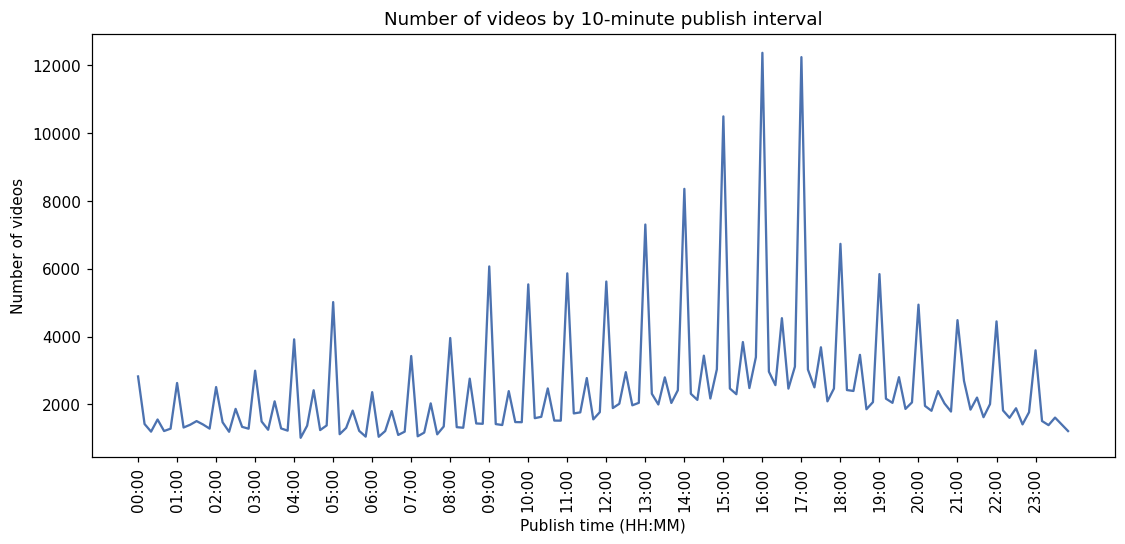

In [17]:
plt.figure(figsize=(12, 5))
plt.plot(interval_stats.index, interval_stats['num_videos'], color='#4C72B0')
plt.title('Number of videos by 10-minute publish interval')
plt.xlabel('Publish time (HH:MM)')
plt.ylabel('Number of videos')
step = 6  # show roughly one label per hour
plt.xticks(range(0, len(interval_stats), step), interval_stats.index[::step], rotation=90)
save_fig('07_videos_by_publish_time.png')
plt.show()

## Task 8 - Number of videos per tag

The `tags` column contains multiple tags separated by `|`. We split them and explode so each tag gets its own row, then count occurrences.

In [18]:
tags = df['tags'][df['tags'] != '[none]'].str.split('|').explode()
videos_per_tag = tags.value_counts()
videos_per_tag

tags
"funny"                              14834
"comedy"                             11900
"2018"                               10567
"news"                                5653
"music"                               5544
                                     ...  
"watch Shahid Kapoor"                    1
"tape cast"                              1
"Film Director"                          1
"shahid kapoor & rajkumar hirani"        1
"langford"                               1
Name: count, Length: 868445, dtype: int64

## Task 9 - Tags with the largest number of videos

Since the previous result is already sorted in descending order, we simply take the top 10.

In [19]:
videos_per_tag.head(10)

tags
"funny"         14834
"comedy"        11900
"2018"          10567
"news"           5653
"music"          5544
"video"          5338
"2017"           5334
"humor"          4992
"television"     4099
"review"         4006
Name: count, dtype: int64

### Visualization - top 10 tags

A horizontal bar chart of the 10 most common tags. The quote characters are part of the raw tag values, so we strip them for readability.

saved: images\09_top_tags.png


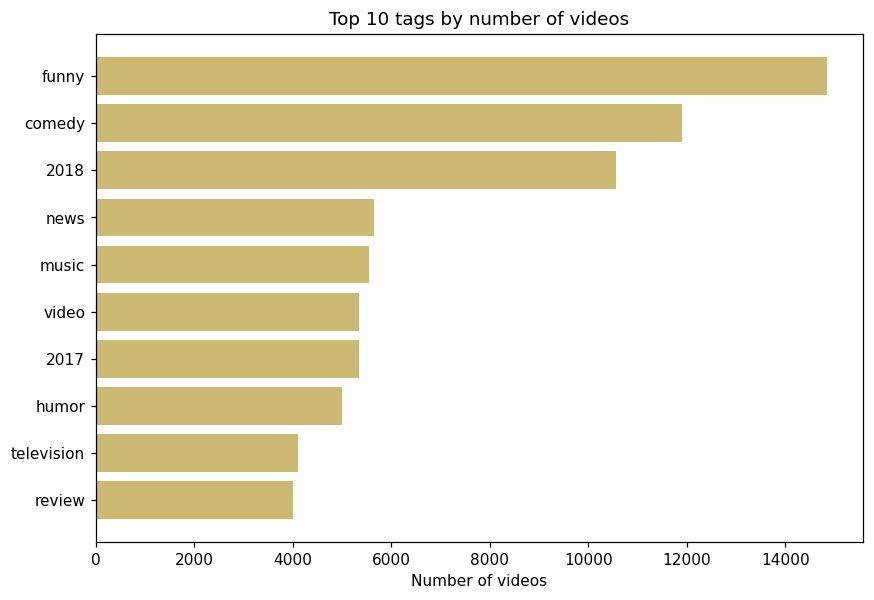

In [20]:
top_tags = videos_per_tag.head(10)
labels = [t.strip('"') for t in top_tags.index]

plt.figure(figsize=(9, 6))
plt.barh(labels[::-1], top_tags.values[::-1], color='#CCB974')
plt.title('Top 10 tags by number of videos')
plt.xlabel('Number of videos')
save_fig('09_top_tags.png')
plt.show()

## Task 10 - Average like/dislike ratio per (tag, country)

For each unique combination of tag and country, we compute the average `like_ratio`. We first filter out videos with no tags, split and explode the tags, then group by `(tags, country)`.

In [21]:
tag_country = df[df['tags'] != '[none]'][['tags', 'country', 'like_ratio']].copy()
tag_country = tag_country.assign(tags=tag_country['tags'].str.split('|')).explode('tags')
tag_country.groupby(['tags', 'country'])['like_ratio'].mean()

tags                                                country
                                                    CA           8.618739
                                                    DE          24.344225
                                                    FR          16.424636
                                                    IN           7.652585
                                                    JP           9.894877
                                                                  ...    
ＮＨＫ                                                 JP          10.125000
ＴＨＥカラオケ★バトル                                         JP           7.450000
ｓ１３                                                 JP          15.335714
🍊 Exatlón México 🍉 programa 🍒 88 EP4-👢 14/02/2018🍅  MX           5.750000
🔥BROMA A FALCONY EL SUSTO DE SU VIDA🔥               MX         128.516035
Name: like_ratio, Length: 1114096, dtype: float64

## Task 11 - Most viewed video per (trending_date, country)

For each combination of `trending_date` and `country`, we find the video with the maximum number of views using `idxmax()`.

In [22]:
df.loc[df.groupby(['trending_date', 'country'])['views'].idxmax()][['trending_date', 'country', 'title', 'views']]

,trending_date,country,title,views
3398,17.01.12,CA,Marvel Studios' Avengers: Infinity War Officia...,56367282
44280,17.01.12,DE,Marvel Studios' Avengers: Infinity War Officia...,56367282
85252,17.01.12,FR,Avengers: Infinity War Trailer Tease,7281189
126032,17.01.12,GB,"Luis Fonsi, Demi Lovato - Échame La Culpa",143408235
164617,17.01.12,IN,Marvel Studios' Avengers: Infinity War Officia...,56367282
...,...,...,...,...
216792,18.31.05,JP,Maroon 5 - Girls Like You ft. Cardi B,3057987
251198,18.31.05,KR,[MV] AOA _ Bingle Bangle(빙글뱅글),4150448
291483,18.31.05,MX,"Cardi B, Bad Bunny & J Balvin - I Like It [Off...",20723565
332058,18.31.05,RU,[BadComedian] - Движение Вверх (Плагиат или ве...,3125598


## Task 12 - Split `trending_date` into year, month, day

The `trending_date` format is `YY.DD.MM` (e.g. `17.14.11` means November 14, 2017). We split on `.` and assign the three parts to new columns, prepending `20` to the year.

In [23]:
parts = df['trending_date'].str.split('.', expand=True)
df['year'] = '20' + parts[0]
df['day'] = parts[1]
df['month'] = parts[2]

df[['trending_date', 'year', 'month', 'day']].head()

,trending_date,year,month,day
0,17.14.11,2017,11,14
1,17.14.11,2017,11,14
2,17.14.11,2017,11,14
3,17.14.11,2017,11,14
4,17.14.11,2017,11,14


### Visualization - trending entries per month

Counting rows by month gives a sense of how the data is spread across the calendar.

saved: images\12_entries_per_month.png


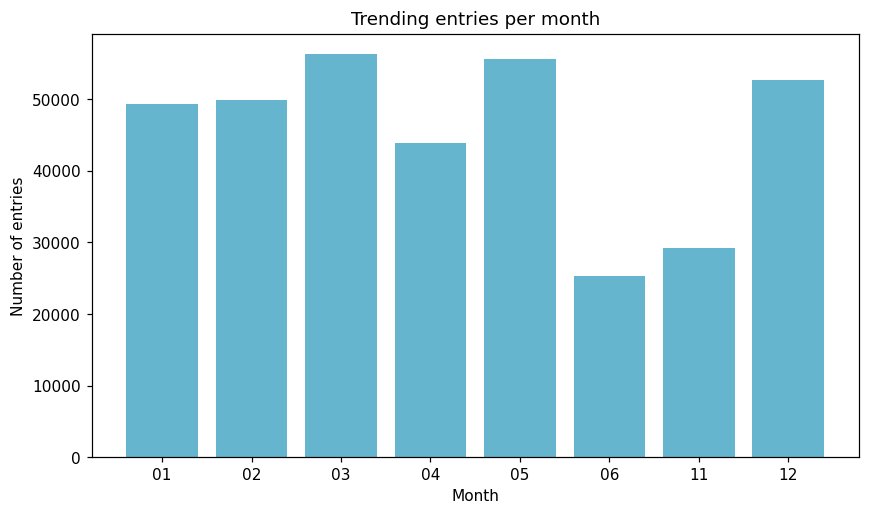

In [24]:
month_counts = df['month'].value_counts().sort_index()

plt.figure(figsize=(9, 5))
plt.bar(month_counts.index, month_counts.values, color='#64B5CD')
plt.title('Trending entries per month')
plt.xlabel('Month')
plt.ylabel('Number of entries')
save_fig('12_entries_per_month.png')
plt.show()

## Task 13 - Most viewed video per (month, country)

Using the newly created `month` column, we find the video with the largest number of views for each (month, country) pair.

In [25]:
df.loc[df.groupby(['month', 'country'])['views'].idxmax()][['month', 'country', 'title', 'views']]

,month,country,title,views
11214,01,CA,Bruno Mars - Finesse (Remix) [Feat. Cardi B] [...,43067983
51930,01,DE,Bruno Mars - Finesse (Remix) [Feat. Cardi B] [...,37728802
92853,01,FR,Bruno Mars - Finesse (Remix) [Feat. Cardi B] [...,37728802
135208,01,GB,Bruno Mars - Finesse (Remix) [Feat. Cardi B] [...,90598955
173405,01,IN,"Taylor Swift - End Game ft. Ed Sheeran, Future",42019590
...,...,...,...,...
166769,12,IN,YouTube Rewind: The Shape of 2017 | #YouTubeRe...,125432237
224092,12,KR,YouTube Rewind: The Shape of 2017 | #YouTubeRe...,113876217
259064,12,MX,YouTube Rewind: The Shape of 2017 | #YouTubeRe...,100912384
299087,12,RU,YouTube Rewind: The Shape of 2017 | #YouTubeRe...,52611730


## Task 14 - Read all JSON category files

Each country has a JSON file mapping `category_id` to a category name and an `assignable` flag. We load all of them into a dictionary keyed by country code.

In [26]:
import json

categories = {}
with zipfile.ZipFile(zip_path) as z:
    for country in countries:
        with z.open(f"trendingYT/{country}_category_id.json") as f:
            data = json.load(f)
        categories[country] = {
            int(item['id']): item['snippet']
            for item in data['items']
        }

# Quick check: show US categories as example
for cat_id, info in list(categories['US'].items())[:5]:
    print(f"{cat_id}: {info['title']} (assignable: {info['assignable']})")

1: Film & Animation (assignable: True)
2: Autos & Vehicles (assignable: True)
10: Music (assignable: True)
15: Pets & Animals (assignable: True)
17: Sports (assignable: True)


### Visualization - top categories in the US

Using the US category map, we translate each `category_id` to its name and count how many US videos fall into each category.

saved: images\14_top_us_categories.png


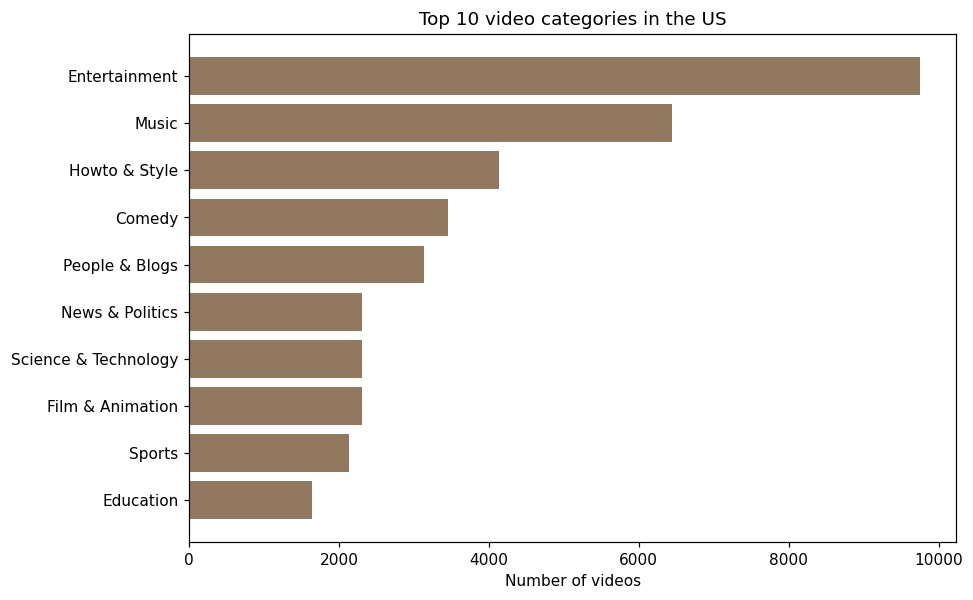

In [27]:
us = df[df['country'] == 'US'].copy()
us_cat_names = us['category_id'].map(lambda cid: categories['US'].get(cid, {}).get('title', 'Unknown'))
us_cat_counts = us_cat_names.value_counts().head(10)

plt.figure(figsize=(9, 6))
plt.barh(us_cat_counts.index[::-1], us_cat_counts.values[::-1], color='#937860')
plt.title('Top 10 video categories in the US')
plt.xlabel('Number of videos')
save_fig('14_top_us_categories.png')
plt.show()

## Task 15 - Videos with non-assignable categories per country

For each country, we identify which `category_id` values are marked as `assignable: false` in the JSON, then count how many videos in the dataframe have one of those category IDs.

In [28]:
not_assignable_counts = {}
for country in countries:
    not_assignable_ids = [
        cat_id for cat_id, info in categories[country].items()
        if not info['assignable']
    ]
    count = df[(df['country'] == country) & (df['category_id'].isin(not_assignable_ids))].shape[0]
    not_assignable_counts[country] = count

not_assignable_series = pd.Series(not_assignable_counts, name='not_assignable_videos')
not_assignable_series

CA    130
DE    102
FR    110
GB     20
IN    220
JP      0
KR    167
MX      3
RU    183
US     57
Name: not_assignable_videos, dtype: int64

### Visualization - videos in non-assignable categories per country

A final bar chart summarising the Task 15 counts.

saved: images\15_non_assignable_per_country.png


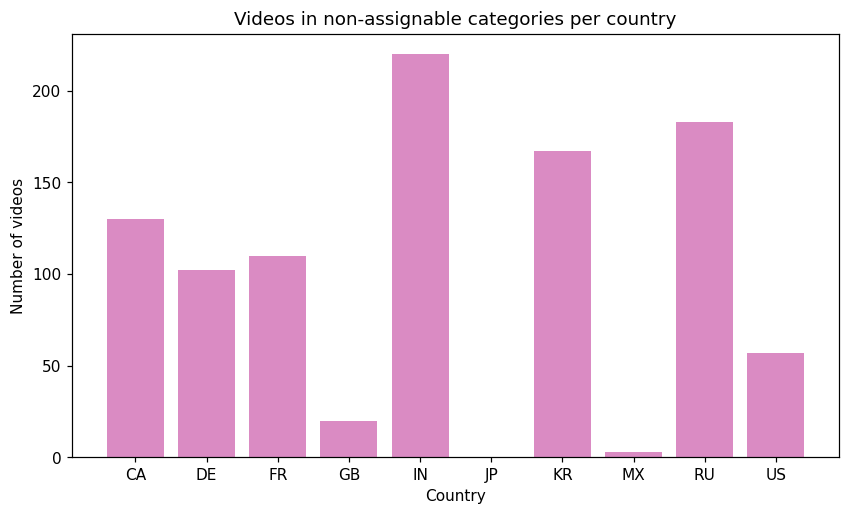

In [29]:
plt.figure(figsize=(9, 5))
plt.bar(not_assignable_series.index, not_assignable_series.values, color='#DA8BC3')
plt.title('Videos in non-assignable categories per country')
plt.xlabel('Country')
plt.ylabel('Number of videos')
save_fig('15_non_assignable_per_country.png')
plt.show()

## Saved charts

All charts produced above are written to the `images` folder next to this notebook. The cell below lists the files that were generated.

In [30]:
for fname in sorted(os.listdir(IMG_DIR)):
    print(fname)

01_entries_per_country.png
02_no_tags_per_country.png
03_top_channels_by_views.png
04_exclusion_reasons.png
05_like_ratio_distribution.png
07_videos_by_publish_time.png
09_top_tags.png
12_entries_per_month.png
14_top_us_categories.png
15_non_assignable_per_country.png
